In [1]:
# 1) Setup & Imports
import os
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import GroupShuffleSplit, GroupKFold, GridSearchCV, StratifiedKFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler
from sklearn.utils import resample

from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC, SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, HistGradientBoostingClassifier

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")

RANDOM_STATE = 42
FEATURE_DIR = Path(r"C:\Users\buck\Napplee\StressClassification\data\features")
FEATURE_FILE = FEATURE_DIR / "features_hrv.csv"
ARTIFACTS_DIR = Path("artifacts")
REPORTS_DIR = Path("reports")

for p in [FEATURE_DIR, ARTIFACTS_DIR, REPORTS_DIR]:
    p.mkdir(parents=True, exist_ok=True)

print(f"Feature file: {FEATURE_FILE}")
print(f"Artifacts directory: {ARTIFACTS_DIR.resolve()}")

Feature file: C:\Users\buck\Napplee\StressClassification\data\features\features_hrv.csv
Artifacts directory: C:\Users\buck\Napplee\StressClassification\artifacts


In [2]:
LABEL_CANDIDATES = ["label", "Label", "stress", "stress_level", "target", "class"]

def find_label_column(df_in: pd.DataFrame):
    for c in LABEL_CANDIDATES:
        if c in df_in.columns:
            return c
    return None

def standardize_features_df(df_in: pd.DataFrame) -> pd.DataFrame:
    out = df_in.copy()
    out = out.loc[:, ~out.columns.astype(str).str.startswith("Unnamed:")].copy()

    label_col = find_label_column(out)
    if label_col is None:
        raise ValueError(
            "Khong tim thay cot label trong feature dataset. Can mot trong cac cot: "
            + ", ".join(LABEL_CANDIDATES)
        )
    if label_col != "label":
        out = out.rename(columns={label_col: "label"})

    out = out.dropna(subset=["label"]).copy()
    if out.empty:
        raise ValueError("Feature dataset rong sau khi loai bo dong thieu label.")

    if "source_file" not in out.columns:
        out["source_file"] = "precomputed_features"
    if "window_id" not in out.columns:
        out["window_id"] = np.arange(len(out))

    if out["label"].dtype == "O" or str(out["label"].dtype).startswith("category"):
        out["label"] = out["label"].astype(str).str.strip()
    else:
        out["label"] = pd.to_numeric(out["label"], errors="coerce")

    out = out.dropna(subset=["label"]).copy()
    if out.empty:
        raise ValueError("Khong con mau nao sau khi chuan hoa cot label.")

    return out

if not FEATURE_FILE.exists():
    raise FileNotFoundError(f"Missing feature file: {FEATURE_FILE}")

features_df = pd.read_csv(FEATURE_FILE)
features_df = standardize_features_df(features_df)

# Ensure Stroop-derived features exist
if {'lf_power', 'hf_power'}.issubset(features_df.columns):
    denom = features_df['lf_power'].fillna(0) + features_df['hf_power'].fillna(0)
    with np.errstate(divide='ignore', invalid='ignore'):
        features_df['lf_nu'] = np.where(denom > 0, (features_df['lf_power'] / denom) * 100.0, np.nan)
        features_df['hf_nu'] = np.where(denom > 0, (features_df['hf_power'] / denom) * 100.0, np.nan)
if {'pnn50', 'n_peaks'}.issubset(features_df.columns) and 'nn50_count' not in features_df.columns:
    rr_count = features_df['n_peaks'].clip(lower=1) - 1
    features_df['nn50_count'] = np.round((features_df['pnn50'] / 100.0) * rr_count).astype('float')

print(f"Feature shape: {features_df.shape}")
print("Class distribution (label):")
print(features_df["label"].value_counts(dropna=False).sort_index())
display(features_df.head())

Feature shape: (2389, 27)
Class distribution (label):
label
0    591
1    608
2    604
3    586
Name: count, dtype: int64


,source_file,window_id,label,mean_rr_ms,median_rr_ms,sdnn_ms,std_rr_ms,rmssd_ms,pnn50,heart_rate_bpm,...,voltage_max,voltage_skew,voltage_kurtosis,lf_power,hf_power,lf_hf_ratio,total_power,lf_nu,hf_nu,nn50_count
0,concatenated/pure_3/concat_3_012.csv,11,3,603.633996,601.562500,38.088,38.087977,18.572,0.000,99.398,...,1.077314,1.332756,2.911622,2500.147013,268.820206,9.300,2769.373062,90.291680,9.708320,0.0
1,concatenated/pure_3/concat_3_074.csv,9,3,622.416178,623.046875,40.161,40.160647,19.220,1.571,96.399,...,1.057756,1.348819,3.000682,2832.490064,258.927013,10.939,3096.576252,91.624326,8.375674,3.0
2,concatenated/mixed_2/mixed_2_010.csv,0,2,715.966504,714.843750,70.404,70.404085,48.427,30.723,83.803,...,1.058959,1.279049,2.888865,6952.372911,2085.341531,3.334,9039.669974,76.926229,23.073771,51.0
3,concatenated/pure_2/concat_2_106.csv,6,2,690.706286,687.500000,89.189,89.189393,85.160,37.791,86.868,...,1.056555,1.194123,2.562684,6525.966986,4704.565390,1.387,11323.211282,58.109151,41.890849,65.0
4,concatenated/pure_2/concat_2_024.csv,0,2,691.428829,687.500000,65.560,65.559887,43.405,26.744,86.777,...,1.050990,1.261661,2.814238,6109.393259,1792.434130,3.408,7903.544739,77.316207,22.683793,46.0


Feature dataset preview:


,source_file,window_id,label,mean_rr_ms,median_rr_ms,sdnn_ms,std_rr_ms,rmssd_ms,pnn50,heart_rate_bpm,...,voltage_max,voltage_skew,voltage_kurtosis,lf_power,hf_power,lf_hf_ratio,total_power,lf_nu,hf_nu,nn50_count
0,concatenated/pure_3/concat_3_012.csv,11,3,603.633996,601.562500,38.088,38.087977,18.572,0.000,99.398,...,1.077314,1.332756,2.911622,2500.147013,268.820206,9.300,2769.373062,90.291680,9.708320,0.0
1,concatenated/pure_3/concat_3_074.csv,9,3,622.416178,623.046875,40.161,40.160647,19.220,1.571,96.399,...,1.057756,1.348819,3.000682,2832.490064,258.927013,10.939,3096.576252,91.624326,8.375674,3.0
2,concatenated/mixed_2/mixed_2_010.csv,0,2,715.966504,714.843750,70.404,70.404085,48.427,30.723,83.803,...,1.058959,1.279049,2.888865,6952.372911,2085.341531,3.334,9039.669974,76.926229,23.073771,51.0
3,concatenated/pure_2/concat_2_106.csv,6,2,690.706286,687.500000,89.189,89.189393,85.160,37.791,86.868,...,1.056555,1.194123,2.562684,6525.966986,4704.565390,1.387,11323.211282,58.109151,41.890849,65.0
4,concatenated/pure_2/concat_2_024.csv,0,2,691.428829,687.500000,65.560,65.559887,43.405,26.744,86.777,...,1.050990,1.261661,2.814238,6109.393259,1792.434130,3.408,7903.544739,77.316207,22.683793,46.0



Describe numeric features:


,count,mean,std,min,25%,50%,75%,max
window_id,2389.0,6.356635,4.052945,0.000000,3.000000,6.000000,10.000000,14.000000
label,2389.0,1.496023,1.111688,0.000000,1.000000,1.000000,2.000000,3.000000
mean_rr_ms,2389.0,666.610633,55.208301,547.233162,623.433431,663.259549,704.604290,804.449958
median_rr_ms,2389.0,664.249719,55.324564,546.875000,621.093750,660.156250,703.125000,800.781250
sdnn_ms,2389.0,63.239046,17.777871,31.072000,49.067000,61.156000,75.331000,117.540000
std_rr_ms,2389.0,63.239056,17.777872,31.071981,49.067396,61.155588,75.331396,117.540168
rmssd_ms,2389.0,47.269056,20.510980,14.371000,30.833000,42.334000,62.837000,101.863000
pnn50,2389.0,21.939121,13.866192,0.000000,10.448000,20.755000,31.788000,61.268000
heart_rate_bpm,2389.0,90.622791,7.467455,74.585000,85.154000,90.462000,96.241000,109.642000
n_peaks,2389.0,179.303267,17.841307,89.505000,169.000000,180.000000,191.000000,219.000000


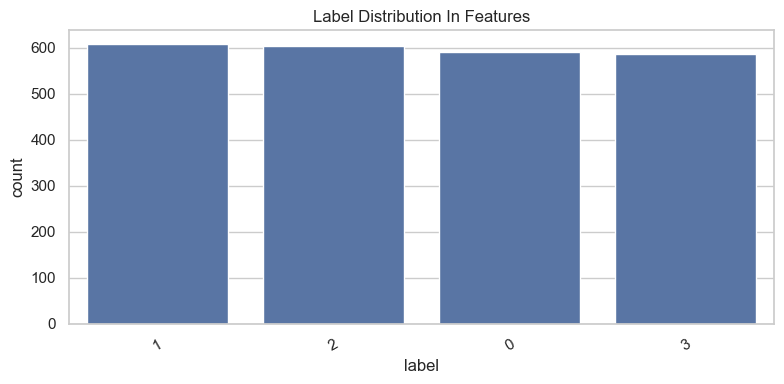

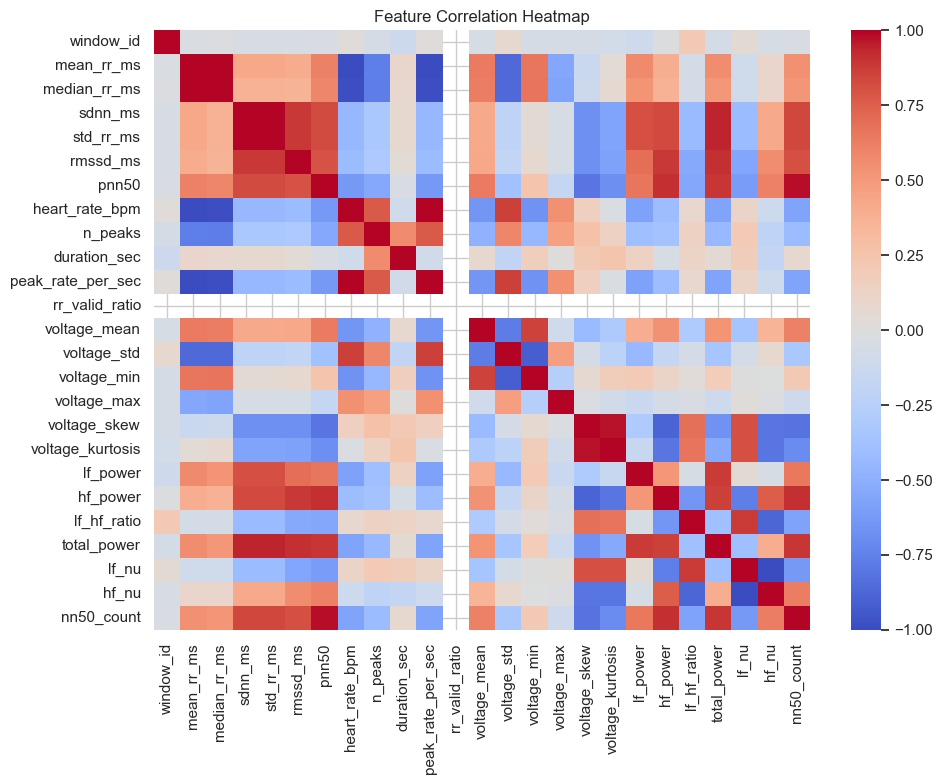

In [5]:
if "label" not in features_df.columns:
    raise ValueError("Khong co cot label trong features_df de train classifier.")

print("Feature dataset preview:")
display(features_df.head())

print("\nDescribe numeric features:")
display(features_df.describe(include=[np.number]).T.head(20))

plt.figure(figsize=(8, 4))
sns.countplot(data=features_df, x="label", order=features_df["label"].value_counts().index)
plt.title("Label Distribution In Features")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

num_cols = [c for c in features_df.select_dtypes(include=[np.number]).columns if c != "label"]
if len(num_cols) >= 2:
    plt.figure(figsize=(10, 8))
    sns.heatmap(features_df[num_cols].corr(numeric_only=True), cmap="coolwarm", center=0)
    plt.title("Feature Correlation Heatmap")
    plt.tight_layout()
    plt.show()

In [3]:
EXPERIMENT_MODE = 'all'  # options: 'all', 'pure_only'
data_model = features_df.copy()
if EXPERIMENT_MODE == 'pure_only' and 'source_file' in data_model.columns:
    src_lower = data_model['source_file'].astype(str).str.lower()
    data_model = data_model[src_lower.str.contains('pure')].copy()
    print(f"Experiment mode: {EXPERIMENT_MODE} -> rows={len(data_model)}")
elif EXPERIMENT_MODE == 'all':
    print(f"Experiment mode: {EXPERIMENT_MODE} -> rows={len(data_model)}")
else:
    print(f"Experiment mode {EXPERIMENT_MODE} khong hop le hoac thieu source_file. Dung toan bo du lieu.")

# Cot giu de trace/ID, khong dua vao feature train
leakage_or_trace_cols = [c for c in ["source_file", "window_id"] if c in data_model.columns]
groups = data_model["source_file"].astype(str).values if "source_file" in data_model.columns else None

X = data_model.drop(columns=["label"] + leakage_or_trace_cols)
y_raw = data_model["label"]

if y_raw.nunique(dropna=True) < 2:
    raise ValueError("Target label chi co 1 lop, khong the train classifier.")

FEATURE_SET_MODE = "all_numeric"  # options: 'hrv_core', 'stroop', 'all_numeric'
HRV_CORE_FEATURES = ["sdnn_ms", "rmssd_ms", "pnn50", "lf_hf_ratio"]
STROOP_FEATURES = [
    "mean_rr_ms",
    "heart_rate_bpm",
    "sdnn_ms",
    "rmssd_ms",
    "nn50_count",
    "pnn50",
    "lf_nu",
    "hf_nu",
    "lf_hf_ratio",
]

if FEATURE_SET_MODE == "hrv_core":
    SELECTED_FEATURES = [f for f in HRV_CORE_FEATURES if f in X.columns]
elif FEATURE_SET_MODE == "stroop":
    SELECTED_FEATURES = [f for f in STROOP_FEATURES if f in X.columns]
else:
    # Prefer all numeric signal features (excluding obvious leakage columns removed above).
    SELECTED_FEATURES = X.select_dtypes(include=[np.number]).columns.tolist()

if not SELECTED_FEATURES:
    raise ValueError("Khong tim thay feature nao de train.")

# Loai bo cot co qua nhieu missing neu co
missing_ratio = X[SELECTED_FEATURES].isna().mean()
SELECTED_FEATURES = [f for f in SELECTED_FEATURES if missing_ratio[f] <= 0.40]
if not SELECTED_FEATURES:
    raise ValueError("Tat ca feature bi loai do missing ratio qua cao.")

# Chi su dung feature theo che do da chon
X = X[SELECTED_FEATURES].copy()

label_encoder = None
if y_raw.dtype == "O" or str(y_raw.dtype).startswith("category"):
    label_encoder = LabelEncoder()
    y = label_encoder.fit_transform(y_raw.astype(str))
    class_names = label_encoder.classes_.tolist()
    print(f"LabelEncoder applied. Classes: {class_names}")
else:
    y = y_raw.astype(int).values
    class_names = sorted(pd.Series(y).dropna().unique().tolist())

numeric_features = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = X.select_dtypes(exclude=[np.number]).columns.tolist()

if len(numeric_features) + len(categorical_features) == 0:
    raise ValueError("Khong con feature hop le de train sau khi loai leakage columns.")

print(f"Modeling samples: {len(X)}")
print(f"Target classes: {class_names}")
print(f"Numeric features: {len(numeric_features)}")
print(f"Categorical features: {len(categorical_features)}")
print(f"Feature mode: {FEATURE_SET_MODE}")
print(f"Features used ({len(SELECTED_FEATURES)}): {SELECTED_FEATURES}")
if groups is not None:
    print(f"Unique groups (source_file): {pd.Series(groups).nunique()}")

# Data-first gate: chi khi du lieu on dinh moi nen focus tuning model
label_counts = pd.Series(y).value_counts()
label_imbalance_ratio = float(label_counts.max() / max(label_counts.min(), 1))
n_unique_sources = int(pd.Series(groups).nunique()) if groups is not None else 0
DATA_QUALITY_READY = (len(X) >= 1200) and (label_imbalance_ratio <= 1.50) and (n_unique_sources >= 80)
print(f"Data gate -> n_samples={len(X)}, imbalance={label_imbalance_ratio:.3f}, unique_sources={n_unique_sources}")
print(f"DATA_QUALITY_READY: {DATA_QUALITY_READY}")

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ],
    remainder="drop",
)

feature_columns = X.columns.tolist()
print(f"Feature columns ({len(feature_columns)}): {feature_columns}")
print(f"Feature matrix shape: {X.shape}")

Experiment mode: all -> rows=2389
Modeling samples: 2389
Target classes: [0, 1, 2, 3]
Numeric features: 24
Categorical features: 0
Feature mode: all_numeric
Features used (24): ['mean_rr_ms', 'median_rr_ms', 'sdnn_ms', 'std_rr_ms', 'rmssd_ms', 'pnn50', 'heart_rate_bpm', 'n_peaks', 'duration_sec', 'peak_rate_per_sec', 'rr_valid_ratio', 'voltage_mean', 'voltage_std', 'voltage_min', 'voltage_max', 'voltage_skew', 'voltage_kurtosis', 'lf_power', 'hf_power', 'lf_hf_ratio', 'total_power', 'lf_nu', 'hf_nu', 'nn50_count']
Unique groups (source_file): 240
Data gate -> n_samples=2389, imbalance=1.038, unique_sources=240
DATA_QUALITY_READY: True
Feature columns (24): ['mean_rr_ms', 'median_rr_ms', 'sdnn_ms', 'std_rr_ms', 'rmssd_ms', 'pnn50', 'heart_rate_bpm', 'n_peaks', 'duration_sec', 'peak_rate_per_sec', 'rr_valid_ratio', 'voltage_mean', 'voltage_std', 'voltage_min', 'voltage_max', 'voltage_skew', 'voltage_kurtosis', 'lf_power', 'hf_power', 'lf_hf_ratio', 'total_power', 'lf_nu', 'hf_nu', 'nn50_

In [4]:
y_series = pd.Series(y)
n_samples = len(X)

if n_samples < 2:
    raise ValueError(
        "So mau sau buoc feature extraction qua it (<2), khong the split train/test."
    )

if y_series.nunique() < 2:
    raise ValueError(
        "Target chi co 1 lop trong du lieu modeling, khong the train classifier."
    )

class_counts = y_series.value_counts()
can_stratify = class_counts.min() >= 2 and y_series.nunique() > 1 and n_samples >= 4

def pick_best_group_split(X_in, y_in, groups_in, test_size=0.2, n_trials=40):
    best = None
    best_score = -1.0
    y_all = pd.Series(y_in)
    global_dist = y_all.value_counts(normalize=True).sort_index()

    for seed in range(RANDOM_STATE, RANDOM_STATE + n_trials):
        gss = GroupShuffleSplit(n_splits=1, test_size=test_size, random_state=seed)
        tr_idx, te_idx = next(gss.split(X_in, y_in, groups=groups_in))
        y_te = pd.Series(y_in[te_idx])
        dist_te = y_te.value_counts(normalize=True).sort_index()

        # Bo qua split neu thieu lop trong test
        if dist_te.shape[0] < global_dist.shape[0]:
            continue

        # Score cao neu phan bo test gan phan bo global va min class ratio cao
        aligned = pd.concat([global_dist, dist_te], axis=1).fillna(0.0)
        aligned.columns = ["global", "test"]
        l1_gap = (aligned["global"] - aligned["test"]).abs().sum()
        min_ratio = float(dist_te.min())
        score = (1.0 - l1_gap) + min_ratio

        if score > best_score:
            best_score = score
            best = (tr_idx, te_idx, seed, dist_te)

    return best

groups_train = None
use_group_split = groups is not None and pd.Series(groups).nunique() >= 10
if use_group_split:
    picked = pick_best_group_split(X, y, groups, test_size=0.2, n_trials=60)
    if picked is None:
        print("Canh bao: khong tim duoc group split can bang. Quay ve split group mac dinh.")
        gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=RANDOM_STATE)
        train_idx, test_idx = next(gss.split(X, y, groups=groups))
        split_seed = RANDOM_STATE
        test_dist = pd.Series(y[test_idx]).value_counts(normalize=True).sort_index()
    else:
        train_idx, test_idx, split_seed, test_dist = picked

    X_train = X.iloc[train_idx].copy()
    X_test = X.iloc[test_idx].copy()
    y_train = y[train_idx]
    y_test = y[test_idx]
    groups_train = pd.Series(groups).iloc[train_idx].astype(str).to_numpy()
    print(f"Split mode: GroupShuffleSplit theo source_file (seed={split_seed}).")
    print("Class distribution in test (group split):")
    print(test_dist)
else:
    stratify_arg = y if can_stratify else None
    if not can_stratify:
        print("Canh bao: khong the stratify do co lop qua it mau. Se split khong stratify.")

    if n_samples == 2:
        test_size = 0.5
    elif n_samples == 3:
        test_size = 1 / 3
    else:
        test_size = 0.2

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=test_size,
        random_state=RANDOM_STATE,
        stratify=stratify_arg,
    )
    if groups is not None:
        groups_series = pd.Series(groups, index=X.index)
        groups_train = groups_series.loc[X_train.index].astype(str).to_numpy()
    print(f"Split mode: train_test_split, test_size={test_size}")

print(f"X_train: {X_train.shape}, y_train: {len(y_train)}")
print(f"X_test:  {X_test.shape}, y_test:  {len(y_test)}")
print("Class distribution in train (raw):")
print(pd.Series(y_train).value_counts(normalize=True).sort_index())

# Can bang nhe train set de ho tro cac model co ban
train_df = X_train.copy()
train_df["__target__"] = y_train
class_size = train_df["__target__"].value_counts().sort_index()
max_size = int(class_size.max())
min_size = int(class_size.min())
imbalance_ratio = (max_size / max(min_size, 1)) if len(class_size) else 1.0

if imbalance_ratio >= 2.5 and groups_train is None:
    balanced_parts = []
    for cls, n_cls in class_size.items():
        cls_df = train_df[train_df["__target__"] == cls]
        if n_cls < max_size:
            cls_df = resample(
                cls_df,
                replace=True,
                n_samples=max_size,
                random_state=RANDOM_STATE,
            )
        balanced_parts.append(cls_df)

    train_balanced = pd.concat(balanced_parts, axis=0, ignore_index=True)
    train_balanced = train_balanced.sample(frac=1.0, random_state=RANDOM_STATE).reset_index(drop=True)
    y_train = train_balanced["__target__"].to_numpy()
    X_train = train_balanced.drop(columns=["__target__"]).copy()
    groups_train = None
    print(f"Applied oversampling because imbalance_ratio={imbalance_ratio:.2f} >= 2.50")
else:
    if imbalance_ratio >= 2.5 and groups_train is not None:
        print(f"Skip oversampling because GroupKFold can bi vo do duplicate rows (imbalance_ratio={imbalance_ratio:.2f}).")
    perm = np.random.RandomState(RANDOM_STATE).permutation(len(X_train))
    X_train = X_train.iloc[perm].reset_index(drop=True)
    y_train = np.asarray(y_train)[perm]
    if groups_train is not None:
        groups_train = np.asarray(groups_train)[perm]
    print(f"Train shuffled without oversampling (imbalance_ratio={imbalance_ratio:.2f}).")

print(f"Final X_train: {X_train.shape}, y_train: {len(y_train)}")
print("Class distribution in train (final):")
print(pd.Series(y_train).value_counts(normalize=True).sort_index())
if groups_train is not None:
    print(f"Unique groups in train: {pd.Series(groups_train).nunique()}")

# Data-first augmentation: chi tao mau moi tren train, khong dong vao test
X_train_model = X_train.copy()
y_train_model = np.asarray(y_train).copy()
groups_train_model = np.asarray(groups_train).copy() if groups_train is not None else None

ENABLE_DATA_FIRST_AUGMENTATION = True
MIN_TRAIN_SAMPLES_TARGET = 1800 if EXPERIMENT_MODE == 'pure_only' else 960
AUG_NOISE_STD_RATIO = 0.02
AUG_CLIP_TO_CLASS_RANGE = True
n_synth_created = 0

if ENABLE_DATA_FIRST_AUGMENTATION and len(X_train_model) < MIN_TRAIN_SAMPLES_TARGET:
    rng = np.random.RandomState(RANDOM_STATE + 99)
    n_need = int(MIN_TRAIN_SAMPLES_TARGET - len(X_train_model))

    train_work = X_train_model.copy()
    train_work["__target__"] = y_train_model
    if groups_train_model is not None:
        train_work["__group__"] = groups_train_model

    numeric_cols_aug = train_work.select_dtypes(include=[np.number]).columns.tolist()
    numeric_cols_aug = [c for c in numeric_cols_aug if c != "__target__"]

    class_counts_aug = train_work["__target__"].value_counts().sort_index()
    alloc = {
        cls: int(np.floor(n_need * (cnt / class_counts_aug.sum())))
        for cls, cnt in class_counts_aug.items()
    }
    remaining = n_need - sum(alloc.values())
    for cls in class_counts_aug.sort_values(ascending=False).index.tolist():
        if remaining <= 0:
            break
        alloc[cls] += 1
        remaining -= 1

    class_stats = {}
    if numeric_cols_aug:
        for cls in class_counts_aug.index:
            cls_num = train_work.loc[train_work["__target__"] == cls, numeric_cols_aug]
            class_stats[cls] = {
                "min": cls_num.min(),
                "max": cls_num.max(),
                "std": cls_num.std(ddof=0).replace(0, 1e-6),
            }

    synth_X_parts = []
    synth_y_parts = []
    synth_g_parts = []

    for cls, n_new in alloc.items():
        if n_new <= 0:
            continue
        cls_rows = train_work[train_work["__target__"] == cls]
        sampled = cls_rows.sample(
            n=n_new,
            replace=True,
            random_state=int(rng.randint(0, 1_000_000)),
        ).reset_index(drop=True)

        if numeric_cols_aug:
            std_vec = class_stats[cls]["std"].values * AUG_NOISE_STD_RATIO
            noise = rng.normal(loc=0.0, scale=std_vec, size=(n_new, len(numeric_cols_aug)))
            sampled.loc[:, numeric_cols_aug] = sampled[numeric_cols_aug].to_numpy() + noise

            if AUG_CLIP_TO_CLASS_RANGE:
                mins = class_stats[cls]["min"]
                maxs = class_stats[cls]["max"]
                sampled.loc[:, numeric_cols_aug] = sampled[numeric_cols_aug].clip(lower=mins, upper=maxs, axis=1)

        drop_cols = ["__target__"] + (["__group__"] if "__group__" in sampled.columns else [])
        synth_X_parts.append(sampled.drop(columns=drop_cols))
        synth_y_parts.append(np.full(n_new, cls, dtype=y_train_model.dtype))
        if "__group__" in sampled.columns:
            synth_g_parts.append(sampled["__group__"].astype(str).to_numpy())

    if synth_X_parts:
        X_synth = pd.concat(synth_X_parts, axis=0, ignore_index=True)
        y_synth = np.concatenate(synth_y_parts)

        X_train_model = pd.concat([X_train_model, X_synth], axis=0, ignore_index=True)
        y_train_model = np.concatenate([y_train_model, y_synth])
        n_synth_created = int(len(X_synth))

        if groups_train_model is not None and synth_g_parts:
            g_synth = np.concatenate(synth_g_parts)
            groups_train_model = np.concatenate([groups_train_model.astype(str), g_synth])

perm_model = np.random.RandomState(RANDOM_STATE + 7).permutation(len(X_train_model))
X_train_model = X_train_model.iloc[perm_model].reset_index(drop=True)
y_train_model = y_train_model[perm_model]
if groups_train_model is not None:
    groups_train_model = np.asarray(groups_train_model)[perm_model]

print(f"Train samples for modeling (after data-first): {len(X_train_model)}")
print(f"Synthetic samples added: {n_synth_created}")
if groups_train_model is not None:
    print(f"Unique groups in modeling train: {pd.Series(groups_train_model).nunique()}")

Split mode: GroupShuffleSplit theo source_file (seed=100).
Class distribution in test (group split):
0    0.226695
1    0.243644
2    0.281780
3    0.247881
Name: proportion, dtype: float64
X_train: (1917, 24), y_train: 1917
X_test:  (472, 24), y_test:  472
Class distribution in train (raw):
0    0.252478
1    0.257173
2    0.245696
3    0.244653
Name: proportion, dtype: float64
Train shuffled without oversampling (imbalance_ratio=1.05).
Final X_train: (1917, 24), y_train: 1917
Class distribution in train (final):
0    0.252478
1    0.257173
2    0.245696
3    0.244653
Name: proportion, dtype: float64
Unique groups in train: 192
Train samples for modeling (after data-first): 1917
Synthetic samples added: 0
Unique groups in modeling train: 192


In [20]:
from sklearn.decomposition import PCA
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.preprocessing import PolynomialFeatures

def make_pipeline(model, extra_steps=None):
    steps = [("preprocessor", preprocessor)]
    if extra_steps:
        steps.extend(extra_steps)
    steps.append(("model", model))
    return Pipeline(steps=steps)

is_binary = len(np.unique(y_train_model)) == 2
TUNING_OBJECTIVE = "accuracy"
primary_scoring = TUNING_OBJECTIVE

# Focus profile: optimize only KNN, Logistic, RandomForest, SVM.
# Extra focus: boost accuracy while keeping Logistic + KNN gains.
ENABLE_MODEL_TUNING = True
INCLUDE_NON_BALANCED_BASELINES = True
SECOND_PASS_TUNING = True

model_spaces = {
    "LogisticRegression_balanced": {
        "extra_steps": [("poly", PolynomialFeatures(include_bias=False, interaction_only=True))],
        "estimator": LogisticRegression(
            C=12.0,
            max_iter=6000,
            class_weight="balanced",
            random_state=RANDOM_STATE,
            n_jobs=1,
        ),
        "param_grid": ({
            "poly__degree": [2],
            "model__C": [12.0, 16.0],
            "model__solver": ["lbfgs"],
        } if ENABLE_MODEL_TUNING else {}),
    },
    "SVM_RBF_balanced": {
        "estimator": SVC(
            C=24.0,
            kernel="rbf",
            gamma=0.07,
            class_weight="balanced",
            random_state=RANDOM_STATE,
        ),
        "param_grid": ({
            "model__C": [20.0, 24.0, 28.0, 32.0],
            "model__gamma": [0.06, 0.065, 0.07, 0.075, 0.08],
        } if ENABLE_MODEL_TUNING else {}),
    },
    "KNN_basic": {
        "extra_steps": [
            ("select", SelectKBest(score_func=f_classif, k=16)),
            ("pca", PCA(random_state=RANDOM_STATE)),
        ],
        "estimator": KNeighborsClassifier(
            n_neighbors=7,
            weights="distance",
            metric="minkowski",
            p=1,
            algorithm="brute",
            n_jobs=-1,
        ),
        "param_grid": ({
            "select__k": [16, 20],
            "pca__n_components": [None, 20, 22],
            "model__n_neighbors": [5, 7, 9],
            "model__weights": ["distance"],
            "model__metric": ["minkowski"],
            "model__p": [1],
        } if ENABLE_MODEL_TUNING else {}),
    },
    "RandomForest_balanced": {
        "estimator": RandomForestClassifier(
            n_estimators=320,
            max_depth=22,
            min_samples_leaf=1,
            min_samples_split=2,
            max_features="sqrt",
            class_weight="balanced_subsample",
            random_state=RANDOM_STATE,
            n_jobs=1,
        ),
        "param_grid": ({
            "model__n_estimators": [280, 320],
            "model__max_depth": [20, 22],
            "model__min_samples_leaf": [1],
            "model__min_samples_split": [2, 4],
            "model__max_features": ["sqrt"],
        } if ENABLE_MODEL_TUNING else {}),
    },
}

if INCLUDE_NON_BALANCED_BASELINES:
    model_spaces.update({
        "LogisticRegression_basic": {
            "extra_steps": [("poly", PolynomialFeatures(include_bias=False, interaction_only=True))],
            "estimator": LogisticRegression(
                C=16.0,
                max_iter=6000,
                class_weight=None,
                random_state=RANDOM_STATE,
                n_jobs=1,
            ),
            "param_grid": ({
                "poly__degree": [2],
                "model__C": [12.0, 16.0, 20.0],
                "model__solver": ["lbfgs"],
            } if ENABLE_MODEL_TUNING else {}),
        },
        "SVM_RBF_basic": {
            "estimator": SVC(
                C=24.0,
                kernel="rbf",
                gamma=0.07,
                class_weight=None,
                random_state=RANDOM_STATE,
            ),
            "param_grid": ({
                "model__C": [20.0, 24.0, 28.0, 32.0, 36.0],
                "model__gamma": [0.06, 0.065, 0.07, 0.075, 0.08],
            } if ENABLE_MODEL_TUNING else {}),
        },
        "RandomForest_basic": {
            "estimator": RandomForestClassifier(
                n_estimators=320,
                max_depth=24,
                min_samples_leaf=1,
                min_samples_split=2,
                max_features="sqrt",
                class_weight=None,
                random_state=RANDOM_STATE,
                n_jobs=1,
            ),
            "param_grid": ({
                "model__n_estimators": [280, 320],
                "model__max_depth": [22, 24, None],
                "model__min_samples_leaf": [1],
                "model__min_samples_split": [2, 4],
                "model__max_features": ["sqrt"],
            } if ENABLE_MODEL_TUNING else {}),
        },
    })

print("Models to train:", list(model_spaces.keys()))
print(f"ENABLE_MODEL_TUNING={ENABLE_MODEL_TUNING}")
print(f"INCLUDE_NON_BALANCED_BASELINES={INCLUDE_NON_BALANCED_BASELINES}")
print(f"SECOND_PASS_TUNING={SECOND_PASS_TUNING}")
print(f"TUNING_OBJECTIVE={TUNING_OBJECTIVE}")
print("Logistic/KNN booster: PolynomialFeatures + SelectKBest + PCA enabled")
print(f"Training rows used for modeling: {len(X_train_model)}")
print("Training class distribution (modeling):")
print(pd.Series(y_train_model).value_counts(normalize=True).sort_index())

Models to train: ['LogisticRegression_balanced', 'SVM_RBF_balanced', 'KNN_basic', 'RandomForest_balanced', 'LogisticRegression_basic', 'SVM_RBF_basic', 'RandomForest_basic']
ENABLE_MODEL_TUNING=True
INCLUDE_NON_BALANCED_BASELINES=True
SECOND_PASS_TUNING=True
TUNING_OBJECTIVE=accuracy
Logistic/KNN booster: PolynomialFeatures + SelectKBest + PCA enabled
Training rows used for modeling: 1917
Training class distribution (modeling):
0    0.252478
1    0.257173
2    0.245696
3    0.244653
Name: proportion, dtype: float64


In [21]:
import time

def evaluate_model(model_name: str, fitted_model, X_eval, y_eval, is_binary_task: bool):
    y_pred = fitted_model.predict(X_eval)

    result = {
        "model": model_name,
        "accuracy": accuracy_score(y_eval, y_pred),
        "precision_weighted": precision_score(y_eval, y_pred, average="weighted", zero_division=0),
        "recall_weighted": recall_score(y_eval, y_pred, average="weighted", zero_division=0),
        "f1_weighted": f1_score(y_eval, y_pred, average="weighted", zero_division=0),
        "f1_macro": f1_score(y_eval, y_pred, average="macro", zero_division=0),
    }

    if is_binary_task and hasattr(fitted_model, "predict_proba"):
        y_proba = fitted_model.predict_proba(X_eval)[:, 1]
        result["roc_auc"] = roc_auc_score(y_eval, y_proba)
    else:
        result["roc_auc"] = np.nan

    print(f"\n===== {model_name} =====")
    print("Confusion Matrix:")
    print(confusion_matrix(y_eval, y_pred))
    print("\nClassification Report:")
    print(classification_report(y_eval, y_pred, zero_division=0))

    return result


results = []
fitted_models = {}
failed_models = []
search_logs = []

# Keep CV stable while controlling runtime.
if groups_train_model is not None and pd.Series(groups_train_model).nunique() >= 5:
    n_splits = min(4, int(pd.Series(groups_train_model).nunique()))
    cv_strategy = GroupKFold(n_splits=max(n_splits, 3))
    cv_mode = "GroupKFold"
else:
    cv_strategy = StratifiedKFold(n_splits=4, shuffle=True, random_state=RANDOM_STATE)
    cv_mode = "StratifiedKFold"

print(f"CV mode: {cv_mode}")

for model_name, cfg in model_spaces.items():
    try:
        base_pipe = make_pipeline(cfg["estimator"], cfg.get("extra_steps"))
        param_grid = cfg.get("param_grid", {})
        t0 = time.time()
        print(f"\n--- Dang train {model_name} ---")

        if ENABLE_MODEL_TUNING and param_grid:
            search = GridSearchCV(
                estimator=base_pipe,
                param_grid=param_grid,
                scoring=primary_scoring,
                cv=cv_strategy,
                n_jobs=-1,
                refit=True,
                verbose=0,
            )
            if cv_mode == "GroupKFold":
                search.fit(X_train_model, y_train_model, groups=groups_train_model)
            else:
                search.fit(X_train_model, y_train_model)
            fitted = search.best_estimator_
            best_params = search.best_params_
            best_cv = float(search.best_score_)
        else:
            fitted = base_pipe.fit(X_train_model, y_train_model)
            best_params = {}
            best_cv = np.nan

        train_sec = time.time() - t0

        fitted_models[model_name] = fitted
        metrics = evaluate_model(model_name, fitted, X_test, y_test, is_binary)
        metrics["train_seconds"] = round(train_sec, 2)
        metrics["cv_best_score"] = round(best_cv, 4) if pd.notna(best_cv) else np.nan
        metrics["best_params"] = str(best_params) if best_params else "{}"
        metrics["cv_mode"] = cv_mode
        results.append(metrics)
        search_logs.append({"model": model_name, "cv_mode": cv_mode, "cv_best_score": best_cv, "best_params": best_params})
    except KeyboardInterrupt:
        print(f"\nBo qua model {model_name} do bi ngat trong qua trinh train.")
        failed_models.append((model_name, "KeyboardInterrupt"))
    except Exception as ex:
        print(f"\nModel {model_name} loi: {ex}")
        failed_models.append((model_name, str(ex)))

if not results:
    raise ValueError("Tat ca model deu that bai khi train. Kiem tra lai cau hinh model va du lieu.")

results_df = pd.DataFrame(results).sort_values("f1_weighted", ascending=False).reset_index(drop=True)
print("\n=== Model Comparison (sorted by f1_weighted) ===")
display(results_df)

if failed_models:
    print("\nModels bi bo qua/that bai:")
    for name, reason in failed_models:
        print(f"- {name}: {reason}")

if search_logs and ENABLE_MODEL_TUNING:
    print("\nCV tuning summary:")
    for log in search_logs:
        print(f"- {log['model']} [{log['cv_mode']}]: cv_best={log['cv_best_score']:.4f}, params={log['best_params']}")

best_model_name = results_df.loc[0, "model"]
best_model = fitted_models.get(best_model_name)
print(f"Best model hien tai: {best_model_name}")

if is_binary:
    plt.figure(figsize=(7, 5))
    for model_name, fitted_model in fitted_models.items():
        if hasattr(fitted_model, "predict_proba"):
            y_proba = fitted_model.predict_proba(X_test)[:, 1]
            fpr, tpr, _ = roc_curve(y_test, y_proba)
            plt.plot(fpr, tpr, label=model_name)

    plt.plot([0, 1], [0, 1], "k--", alpha=0.7)
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curves (Binary Classification)")
    plt.legend()
    plt.tight_layout()
    plt.show()

CV mode: GroupKFold

--- Dang train LogisticRegression_balanced ---

===== LogisticRegression_balanced =====
Confusion Matrix:
[[ 96   9   2   0]
 [  6  90  14   5]
 [  2  11 103  17]
 [  2   0   6 109]]

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.90      0.90       107
           1       0.82      0.78      0.80       115
           2       0.82      0.77      0.80       133
           3       0.83      0.93      0.88       117

    accuracy                           0.84       472
   macro avg       0.84      0.85      0.84       472
weighted avg       0.84      0.84      0.84       472


--- Dang train SVM_RBF_balanced ---

===== SVM_RBF_balanced =====
Confusion Matrix:
[[ 93  12   2   0]
 [  9  93  11   2]
 [  1   9 113  10]
 [  4   0   6 107]]

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.87      0.87       107
           1       0.82      0.81      0.8

,model,accuracy,precision_weighted,recall_weighted,f1_weighted,f1_macro,roc_auc,train_seconds,cv_best_score,best_params,cv_mode
0,SVM_RBF_basic,0.862288,0.862328,0.862288,0.862267,0.862705,NaN,1.33,0.8252,"{'model__C': 28.0, 'model__gamma': 0.065}",GroupKFold
1,SVM_RBF_balanced,0.860169,0.859902,0.860169,0.860012,0.860249,NaN,3.16,0.8331,"{'model__C': 24.0, 'model__gamma': 0.07}",GroupKFold
2,LogisticRegression_basic,0.847458,0.847527,0.847458,0.846574,0.849206,NaN,3.75,0.7997,"{'model__C': 16.0, 'model__solver': 'lbfgs', '...",GroupKFold
3,LogisticRegression_balanced,0.843220,0.843093,0.843220,0.842143,0.844723,NaN,5.79,0.8101,"{'model__C': 12.0, 'model__solver': 'lbfgs', '...",GroupKFold
4,RandomForest_basic,0.836864,0.836179,0.836864,0.835685,0.837618,NaN,7.86,0.8111,"{'model__max_depth': 24, 'model__max_features'...",GroupKFold
5,RandomForest_balanced,0.826271,0.825287,0.826271,0.825035,0.827243,NaN,6.63,0.8054,"{'model__max_depth': 20, 'model__max_features'...",GroupKFold
6,KNN_basic,0.824153,0.821046,0.824153,0.822160,0.823511,NaN,0.38,0.7778,"{'model__metric': 'minkowski', 'model__n_neigh...",GroupKFold



CV tuning summary:
- LogisticRegression_balanced [GroupKFold]: cv_best=0.8101, params={'model__C': 12.0, 'model__solver': 'lbfgs', 'poly__degree': 2}
- SVM_RBF_balanced [GroupKFold]: cv_best=0.8331, params={'model__C': 24.0, 'model__gamma': 0.07}
- KNN_basic [GroupKFold]: cv_best=0.7778, params={'model__metric': 'minkowski', 'model__n_neighbors': 7, 'model__p': 1, 'model__weights': 'distance', 'pca__n_components': None, 'select__k': 16}
- RandomForest_balanced [GroupKFold]: cv_best=0.8054, params={'model__max_depth': 20, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 1, 'model__min_samples_split': 2, 'model__n_estimators': 280}
- LogisticRegression_basic [GroupKFold]: cv_best=0.7997, params={'model__C': 16.0, 'model__solver': 'lbfgs', 'poly__degree': 2}
- SVM_RBF_basic [GroupKFold]: cv_best=0.8252, params={'model__C': 28.0, 'model__gamma': 0.065}
- RandomForest_basic [GroupKFold]: cv_best=0.8111, params={'model__max_depth': 24, 'model__max_features': 'sqrt', 'model__min_sam

=== Quality Report ===
n_samples: 2389
n_features_total: 27
n_unique_source_files: 240
label_distribution: {0: 591, 1: 608, 2: 604, 3: 586}
imbalance_ratio_max_to_min: 1.0375426621160408
unique_sources_per_label: {0: 60, 1: 60, 2: 60, 3: 60}
top10_null_ratio: {'window_id': 0.0, 'label': 0.0, 'mean_rr_ms': 0.0, 'median_rr_ms': 0.0, 'sdnn_ms': 0.0, 'std_rr_ms': 0.0, 'rmssd_ms': 0.0, 'pnn50': 0.0, 'heart_rate_bpm': 0.0, 'n_peaks': 0.0}
train_samples_for_modeling: 1917
train_class_distribution_for_modeling: {0: 484, 1: 493, 2: 471, 3: 469}
synthetic_samples_added: 0


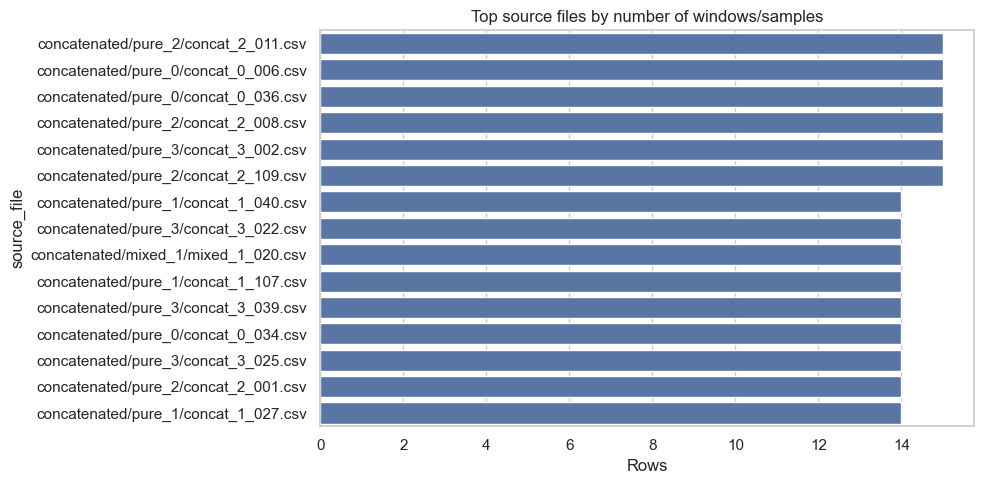

Saved quality report: reports\quality_report_train.json


In [10]:
# Data quality checks for debugging low-score issues
quality_report = {
    "n_samples": int(len(features_df)),
    "n_features_total": int(features_df.shape[1]),
    "n_unique_source_files": int(features_df["source_file"].nunique()) if "source_file" in features_df.columns else None,
    "label_distribution": features_df["label"].value_counts(dropna=False).sort_index().to_dict(),
}

if "label" in features_df.columns:
    label_count = features_df["label"].value_counts()
    quality_report["imbalance_ratio_max_to_min"] = float(label_count.max() / max(label_count.min(), 1))
    if "source_file" in features_df.columns:
        src_per_label = features_df.groupby("label")["source_file"].nunique().sort_index().to_dict()
        quality_report["unique_sources_per_label"] = {int(k): int(v) for k, v in src_per_label.items()}

numeric_cols = features_df.select_dtypes(include=[np.number]).columns.tolist()
if numeric_cols:
    null_ratio = features_df[numeric_cols].isna().mean().sort_values(ascending=False)
    quality_report["top10_null_ratio"] = {k: float(v) for k, v in null_ratio.head(10).items()}

if "X_train_model" in globals() and "y_train_model" in globals():
    quality_report["train_samples_for_modeling"] = int(len(X_train_model))
    quality_report["train_class_distribution_for_modeling"] = pd.Series(y_train_model).value_counts(dropna=False).sort_index().to_dict()
if "n_synth_created" in globals():
    quality_report["synthetic_samples_added"] = int(n_synth_created)

print("=== Quality Report ===")
for k, v in quality_report.items():
    print(f"{k}: {v}")

if "source_file" in features_df.columns:
    src_counts = features_df["source_file"].value_counts().head(15)
    plt.figure(figsize=(10, 5))
    sns.barplot(x=src_counts.values, y=src_counts.index, orient="h")
    plt.title("Top source files by number of windows/samples")
    plt.xlabel("Rows")
    plt.ylabel("source_file")
    plt.tight_layout()
    plt.show()

report_path = REPORTS_DIR / "quality_report_train.json"
pd.Series({k: str(v) for k, v in quality_report.items()}).to_json(report_path, force_ascii=False, indent=2)
print(f"Saved quality report: {report_path}")

In [7]:
# Quick summary after training (focused 4 models)
if 'results_df' in globals() and isinstance(results_df, pd.DataFrame):
    cols = ['model', 'accuracy', 'f1_weighted', 'f1_macro', 'train_seconds', 'cv_best_score', 'best_params']
    cols = [c for c in cols if c in results_df.columns]
    print('Focused model results (KNN, Logistic, RandomForest, SVM):')
    display(results_df[cols].head(10))
else:
    print('results_df not available yet. Run Cell 7 first.')

Focused model results (KNN, Logistic, RandomForest, SVM):


,model,accuracy,f1_weighted,f1_macro,train_seconds,cv_best_score,best_params
0,SVM_RBF_balanced,0.851695,0.851293,0.851393,3.20,0.8066,"{'model__C': 12.0, 'model__gamma': 0.1}"
1,RandomForest_balanced,0.830508,0.829444,0.831532,17.41,0.8013,"{'model__max_depth': None, 'model__max_feature..."
2,KNN_basic,0.815678,0.814448,0.816746,0.85,0.7684,"{'model__metric': 'minkowski', 'model__n_neigh..."
3,LogisticRegression_balanced,0.754237,0.751139,0.756283,6.24,0.7232,{'model__C': 8.0}
